# Data Analysis of Reddit ADHD data.

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from transformers import pipeline
import torch
import random
from empath import Empath
from operator import itemgetter

In [2]:
sns.set_theme(context="notebook",style="whitegrid")
sns.set_palette("colorblind")

### Files and folder names

In [3]:
user_file = "./files/260515_users.csv"
content_file = "./files/260515_content.csv"
media_folder = "./media/"

## General Statistics

In [4]:
users_df = pd.read_csv(user_file)
content_df = pd.read_csv(content_file)
join_data = users_df.merge(content_df,left_on="id",right_on="user",how="left")

In [5]:
print("USERS DATASET")
print(f"Shape: {users_df.shape}")
print(f"Columns: {users_df.columns.tolist()}")
print(f"Number of users: {len(users_df)}")
print(users_df.head())

USERS DATASET
Shape: (6847, 18)
Columns: ['id', 'has_ADHD', 'first_found_in', 'n_comments', 'n_posts', 'n_content', 'char_mean_comment', 'char_mean_post', 'char_median_comment', 'char_median_post', 'char_std_comment', 'char_std_post', 'word_mean_comment', 'word_mean_post', 'word_median_comment', 'word_median_post', 'word_std_comment', 'word_std_post']
Number of users: 6847
                 id  has_ADHD first_found_in  n_comments  n_posts  n_content  \
0  5a337749c7ef9cd7     False         r/ADHD          57        0         57   
1  8f3ed796133a5366     False         r/ADHD           8        0          8   
2  921f78eba6554243     False         r/ADHD          46        3         49   
3  827a44707aad1bc7      True         r/ADHD          23        3         26   
4  10bcc41b6bca3ddf     False         r/ADHD          11        0         11   

   char_mean_comment  char_mean_post  char_median_comment  char_median_post  \
0         368.491228             NaN                335.0       

In [6]:
print("CONTENT DATASET")
print(f"Shape: {content_df.shape}")
print(f"Columns: {content_df.columns.tolist()}")
print(f"Number of users: {len(content_df)}")
print(content_df.head())

CONTENT DATASET
Shape: (1994787, 10)
Columns: ['id', 'user', 'type', 'subreddit', 'text', 'timestamp', 'has_ADHD_pattern', 'has_media', 'char_count', 'word_count']
Number of users: 1994787
                 id              user     type                subreddit  \
0  2a186f66070c29f8  5a337749c7ef9cd7  comment       r/IndiaAlgoTrading   
1  37313f63427777c4  5a337749c7ef9cd7  comment               r/branding   
2  03651818244e8250  5a337749c7ef9cd7  comment            r/NoFreeSpins   
3  90bb790ffa44eaef  5a337749c7ef9cd7  comment  r/EntrepreneurRideAlong   
4  b5b8710b319bcbe9  5a337749c7ef9cd7  comment          r/CurlyHairCare   

                                                text  \
0  i think its really clever that people use corr...   
1  Make sure you balance your numbers. Having 10k...   
2  Check the game providers on a few sites side b...   
3  Just keep posting reels, that's the only way t...   
4  Girl, bonnets are a total game-changer for hai...   

                   time

In [7]:
total_files = 0
for root, dirs, files in os.walk(media_folder):
    total_files += len(files)
    
print(f"Number of images obtained: {total_files}")

Number of images obtained: 15770


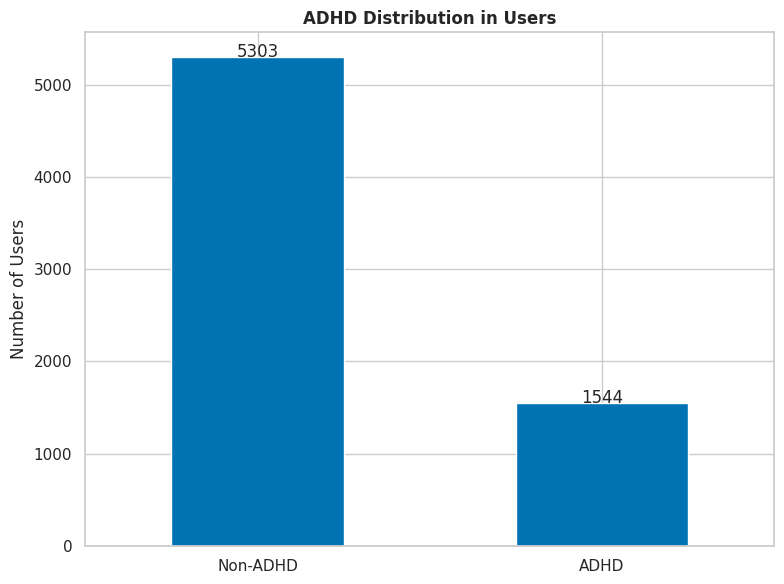

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
adhd_counts = users_df.groupby('has_ADHD').size()
adhd_counts.index = ['Non-ADHD' if not x else 'ADHD' for x in adhd_counts.index]
bars = adhd_counts.plot(kind='bar', ax=ax)
ax.set_title('ADHD Distribution in Users', fontweight='bold')
ax.set_ylabel('Number of Users')
ax.tick_params(axis='x', rotation=0)

#valores en las barras
for i, v in enumerate(adhd_counts.values):
    ax.text(i, v + 0.5, str(v), ha='center')

plt.tight_layout()
plt.show()

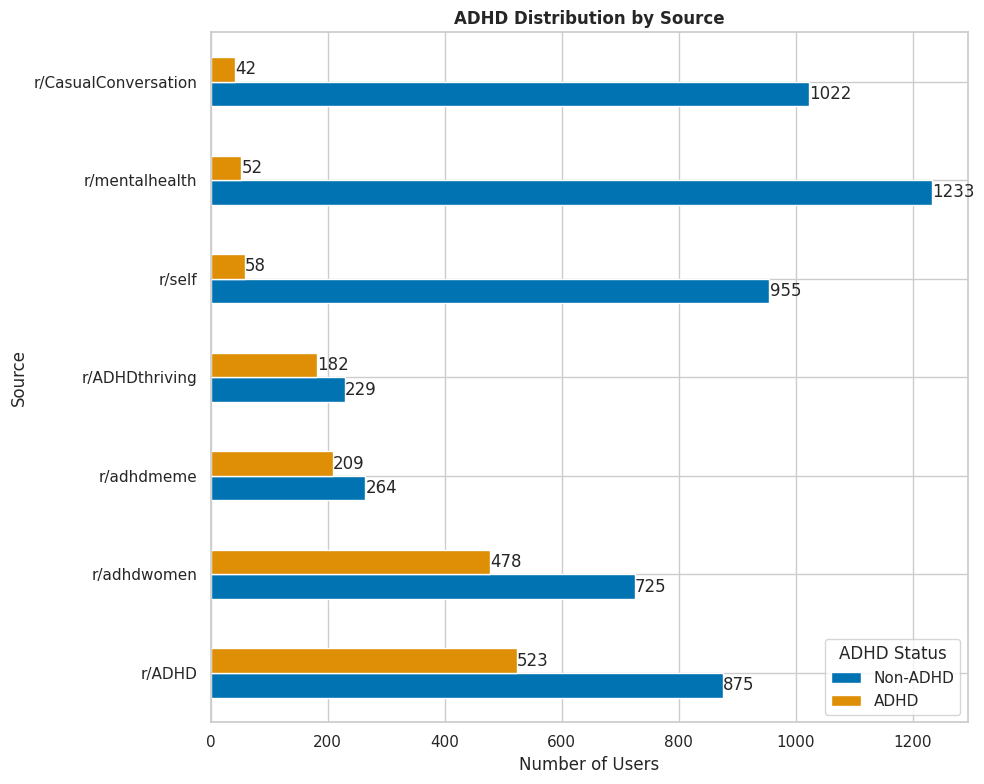

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

adhd_by_source = pd.crosstab(users_df['first_found_in'], users_df['has_ADHD'])
adhd_by_source.columns = ['Non-ADHD', 'ADHD']
adhd_by_source = adhd_by_source.sort_values('ADHD', ascending=False)

bars = adhd_by_source.plot(kind='barh', ax=ax)

ax.set_title('ADHD Distribution by Source', fontweight='bold')
ax.set_xlabel('Number of Users')
ax.set_ylabel('Source')
ax.legend(title='ADHD Status')
    
for i, (idx, row) in enumerate(adhd_by_source.iterrows()):
    if row['Non-ADHD'] > 0:
        ax.text(row['Non-ADHD'] + 0.5, i-0.125, str(row['Non-ADHD']),va='center')
    if row['ADHD'] > 0:
        ax.text(row['ADHD'] + 0.5, i+0.125, str(row['ADHD']),va='center')

plt.tight_layout()
plt.show()

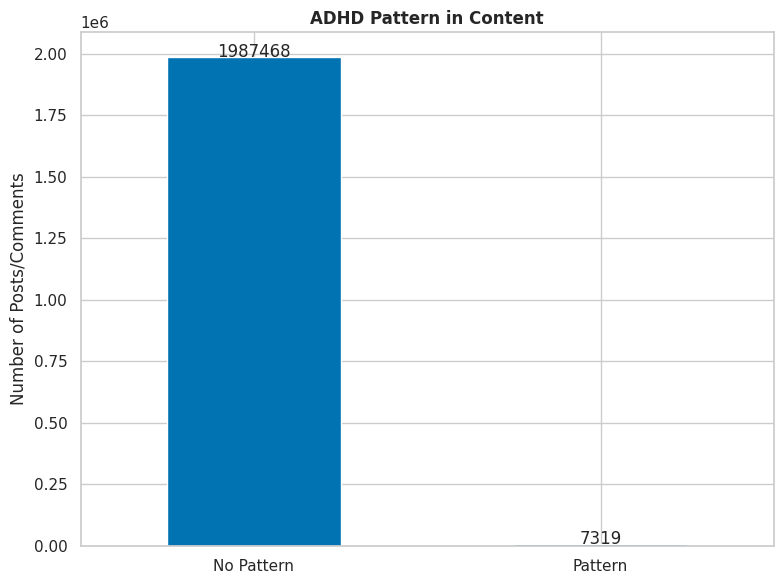

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
pattern_counts = content_df.groupby('has_ADHD_pattern').size()
pattern_counts.index = ['No Pattern' if not x else 'Pattern' for x in pattern_counts.index]
bars = pattern_counts.plot(kind='bar', ax=ax)
ax.set_title('ADHD Pattern in Content', fontweight='bold')
ax.set_ylabel('Number of Posts/Comments')
ax.tick_params(axis='x', rotation=0)

for i, v in enumerate(pattern_counts.values):
    ax.text(i, v + 0.1, str(v), ha='center')

plt.tight_layout()
plt.show()

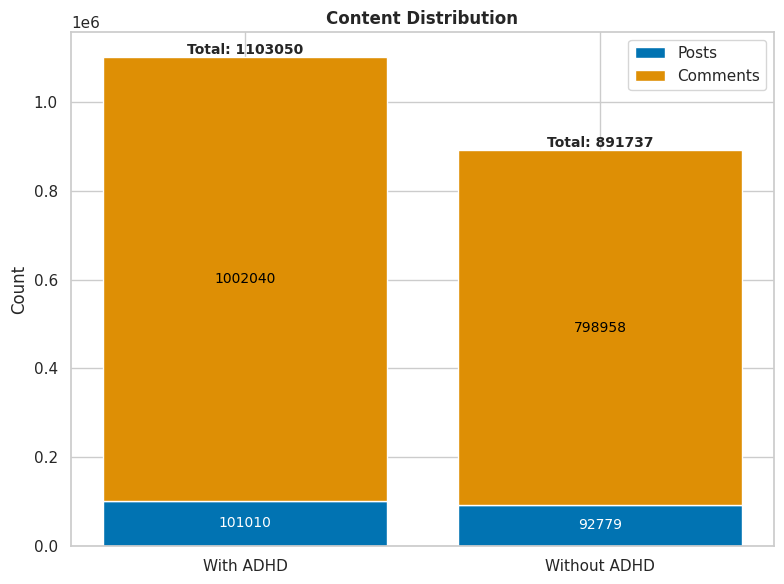

In [11]:
import matplotlib.pyplot as plt
import numpy as np


adhd_data = users_df[users_df['has_ADHD'] == True]
non_adhd_data = users_df[users_df['has_ADHD'] == False]

adhd_posts = adhd_data['n_posts'].sum()
adhd_comments = adhd_data['n_comments'].sum()
non_adhd_posts = non_adhd_data['n_posts'].sum()
non_adhd_comments = non_adhd_data['n_comments'].sum()

groups = ['With ADHD', 'Without ADHD']
posts = [adhd_posts, non_adhd_posts]
comments = [adhd_comments, non_adhd_comments]

fig, ax = plt.subplots(figsize=(8, 6))

bar1 = ax.bar(groups, posts, label='Posts')
bar2 = ax.bar(groups, comments, bottom=posts, label='Comments')

for i, (group, post_val, comment_val) in enumerate(zip(groups, posts, comments)):
    #posts
    if post_val > 0:
        ax.text(i, post_val/2, f'{int(post_val)}', 
               ha='center', va='center', color='white', fontsize=10)
    
    #comentarios
    if comment_val > 0:
        ax.text(i, post_val + comment_val/2, f'{int(comment_val)}', 
               ha='center', va='center', color='black', fontsize=10)
    
    #total
    total = post_val + comment_val
    ax.text(i, total, f'Total: {int(total)}', 
           ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Content Distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()

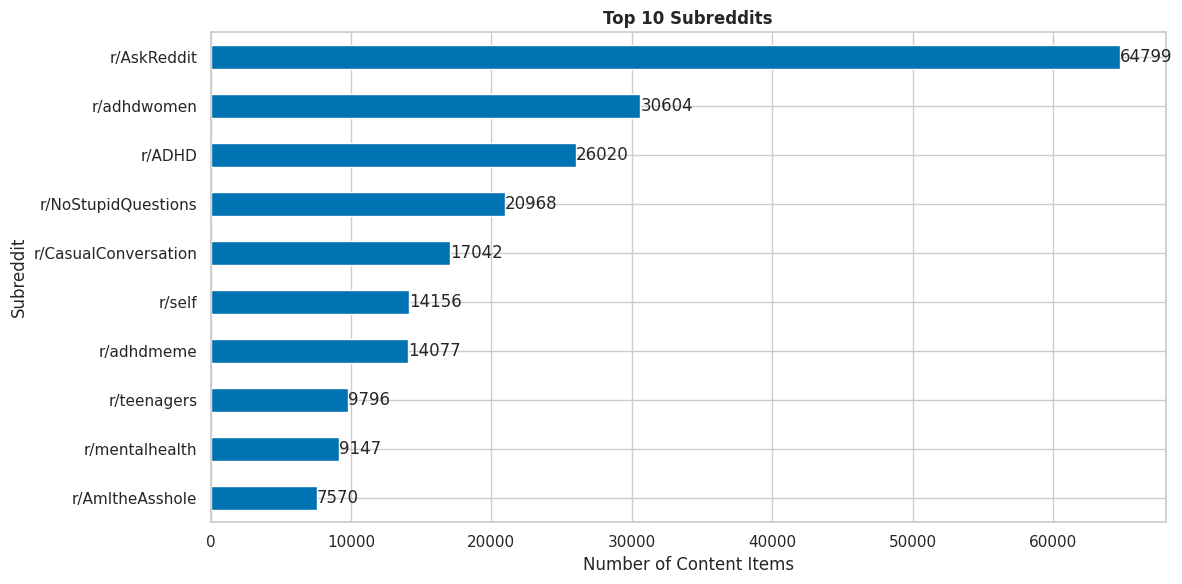

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
subreddit_counts = content_df['subreddit'].value_counts().head(10).sort_values(ascending=True)
bars = subreddit_counts.plot(kind='barh', ax=ax)
ax.set_title('Top 10 Subreddits', fontweight='bold')
ax.set_ylabel('Subreddit')
ax.set_xlabel('Number of Content Items')

for i, v in enumerate(subreddit_counts.values):
    ax.text(v + 0.5, i, str(v), va='center')

plt.tight_layout()
plt.show()

## Text Counts

### Content quantity analysis

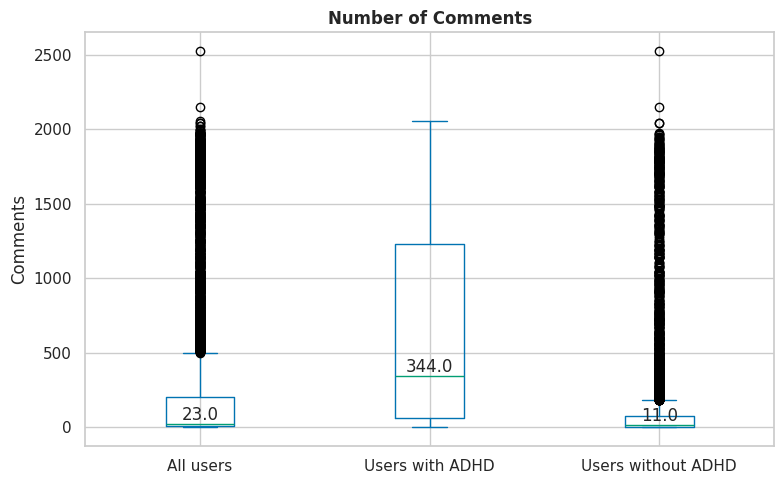

In [5]:
df_ncomments = pd.DataFrame({
    'All users': users_df["n_comments"],
    'Users with ADHD': users_df.loc[users_df["has_ADHD"]==True,"n_comments"],
    'Users without ADHD': users_df.loc[users_df["has_ADHD"]==False,"n_comments"],
})

fig, ax = plt.subplots(figsize=(8, 5))
df_ncomments.plot(kind='box',ax=ax)
ax.set_title('Number of Comments',fontweight='bold')
ax.set_ylabel('Comments')

medians = df_ncomments.median()
for i, (col, median_val) in enumerate(medians.items(), start=1):
    ax.text(i, median_val, f'{median_val:.1f}', 
            horizontalalignment='center', verticalalignment='bottom')

plt.tight_layout()
plt.show()

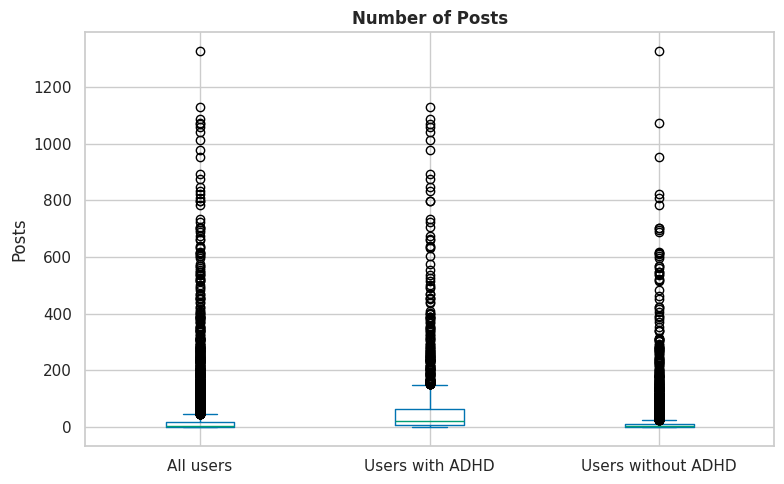

In [6]:
df_nposts = pd.DataFrame({
    'All users': users_df["n_posts"],
    'Users with ADHD': users_df.loc[users_df["has_ADHD"]==True,"n_posts"],
    'Users without ADHD': users_df.loc[users_df["has_ADHD"]==False,"n_posts"],
})

fig, ax = plt.subplots(figsize=(8, 5))
df_nposts.plot(kind='box',ax=ax)
ax.set_title('Number of Posts',fontweight='bold')
ax.set_ylabel('Posts')

plt.tight_layout()
plt.show()

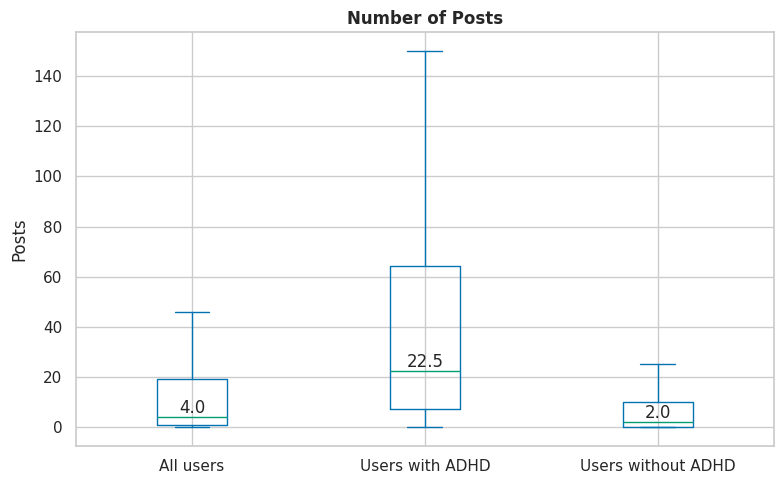

In [7]:
df_nposts = pd.DataFrame({
    'All users': users_df["n_posts"],
    'Users with ADHD': users_df.loc[users_df["has_ADHD"]==True,"n_posts"],
    'Users without ADHD': users_df.loc[users_df["has_ADHD"]==False,"n_posts"],
})

fig, ax = plt.subplots(figsize=(8, 5))
df_nposts.plot(kind='box',ax=ax,showfliers=False)
ax.set_title('Number of Posts',fontweight='bold')
ax.set_ylabel('Posts')

medians = df_nposts.median()
for i, (col, median_val) in enumerate(medians.items(), start=1):
    ax.text(i, median_val, f'{median_val:.1f}', 
            horizontalalignment='center', verticalalignment='bottom')

plt.tight_layout()
plt.show()

### Content length analysis

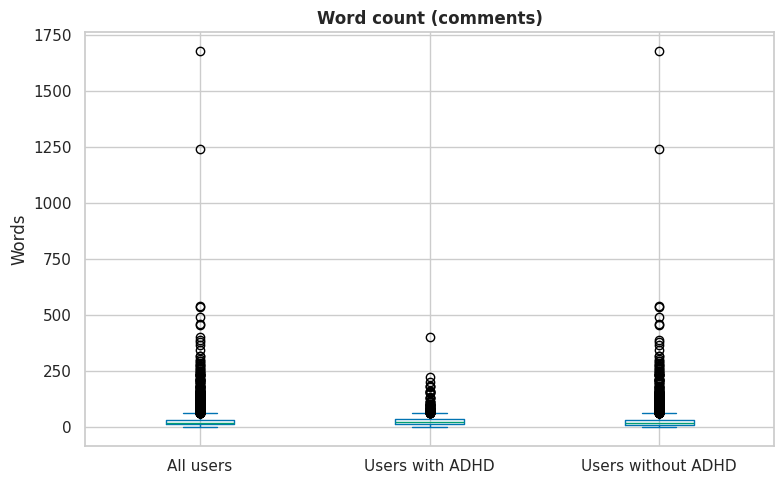

In [8]:
len_data = content_df.groupby(["user","type"])[["char_count","word_count"]].median().reset_index()

len_data = len_data.merge(users_df,left_on="user",right_on="id",how='left')

len_data_all_comments = len_data[len_data["type"] == "comment"]
len_data_adhd_comments = len_data[(len_data["has_ADHD"] == True) & (len_data["type"] == "comment")]
len_data_not_adhd_comments = len_data[(len_data["has_ADHD"] == False) & (len_data["type"] == "comment")]

fig, ax = plt.subplots(figsize=(8, 5))
df_comments = pd.DataFrame({
    'All users':len_data_all_comments["word_count"],
    'Users with ADHD':len_data_adhd_comments["word_count"],
    'Users without ADHD':len_data_not_adhd_comments["word_count"]})

df_comments.plot(kind='box',ax=ax)
ax.set_title('Word count (comments)',fontweight='bold')
ax.set_ylabel('Words')

plt.tight_layout()
plt.show()

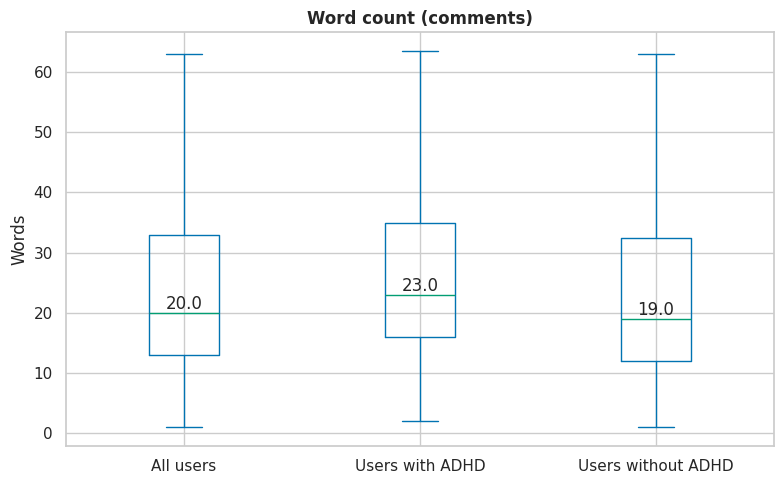

In [9]:
fig, ax = plt.subplots(figsize=(8,5))
df_comments = pd.DataFrame({
    'All users':len_data_all_comments["word_count"],
    'Users with ADHD':len_data_adhd_comments["word_count"],
    'Users without ADHD':len_data_not_adhd_comments["word_count"]})

df_comments.plot(kind='box',ax=ax,showfliers=False)
ax.set_title('Word count (comments)',fontweight='bold')
ax.set_ylabel('Words')

medians = df_comments.median()
for i, (col, median_val) in enumerate(medians.items(), start=1):
    ax.text(i, median_val, f'{median_val:.1f}', 
            horizontalalignment='center', verticalalignment='bottom')

plt.tight_layout()
plt.show()

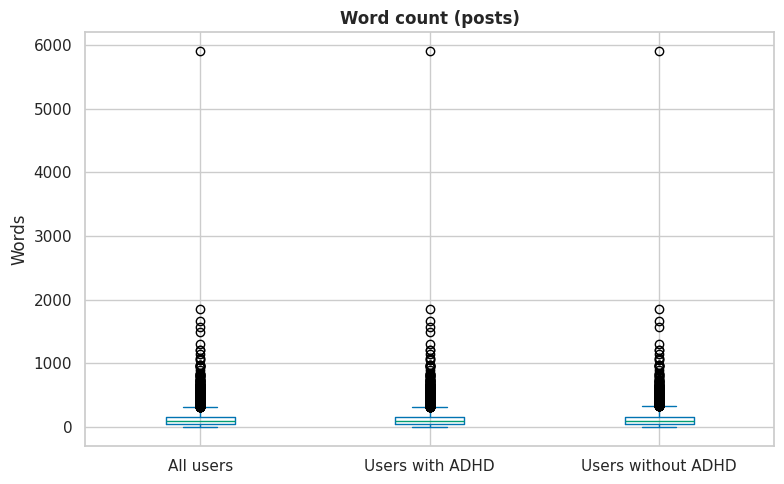

In [10]:
len_data_all_posts = len_data[len_data["type"] == "post"]
len_data_adhd_posts = len_data[(len_data["has_ADHD"] == True) & (len_data["type"] == "post")]
len_data_not_adhd_posts = len_data[(len_data["has_ADHD"] == False) & (len_data["type"] == "post")]

fig, ax = plt.subplots(figsize=(8, 5))
df_posts = pd.DataFrame({
    'All users':len_data_all_posts["word_count"],
    'Users with ADHD':len_data_all_posts["word_count"],
    'Users without ADHD':len_data_not_adhd_posts["word_count"]})

df_posts.plot(kind='box',ax=ax)
ax.set_title('Word count (posts)',fontweight='bold')
ax.set_ylabel('Words')

plt.tight_layout()
plt.show()

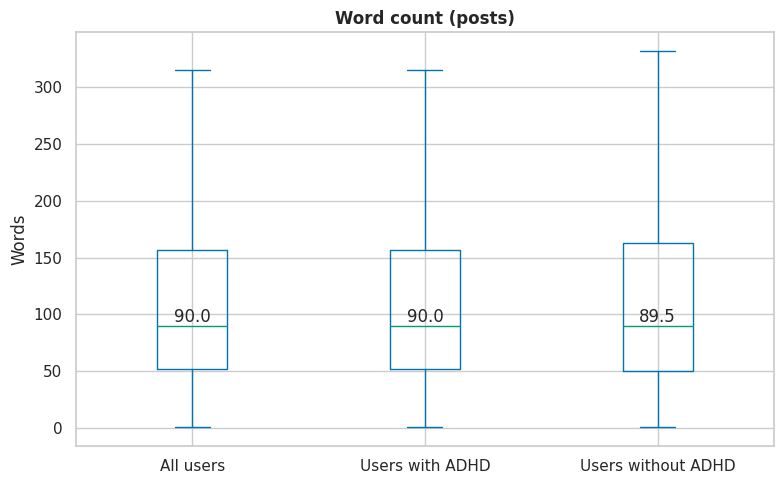

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
df_posts = pd.DataFrame({
    'All users':len_data_all_posts["word_count"],
    'Users with ADHD':len_data_all_posts["word_count"],
    'Users without ADHD':len_data_not_adhd_posts["word_count"]})

df_posts.plot(kind='box',ax=ax,showfliers=False)
ax.set_title('Word count (posts)',fontweight='bold')
ax.set_ylabel('Words')

medians = df_posts.median()
for i, (col, median_val) in enumerate(medians.items(), start=1):
    ax.text(i, median_val, f'{median_val:.1f}', 
            horizontalalignment='center', verticalalignment='bottom')

plt.tight_layout()
plt.show()

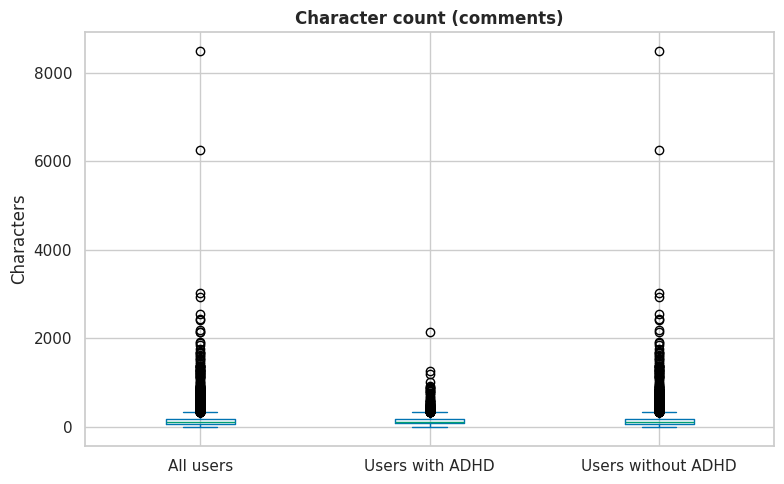

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
df_comments_len = pd.DataFrame({
    'All users':len_data_all_comments["char_count"],
    'Users with ADHD':len_data_adhd_comments["char_count"],
    'Users without ADHD':len_data_not_adhd_comments["char_count"]})

df_comments_len.plot(kind='box',ax=ax)
ax.set_title('Character count (comments)',fontweight='bold')
ax.set_ylabel('Characters')

plt.tight_layout()
plt.show()

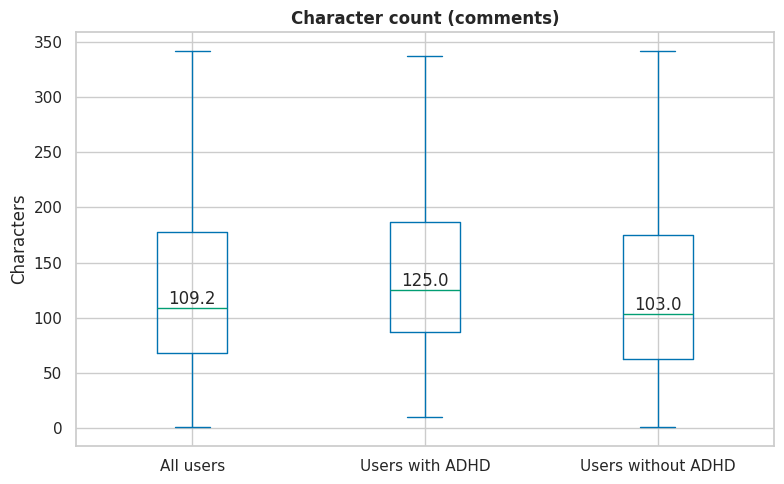

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

df_comments_len.plot(kind='box',ax=ax,showfliers=False)
ax.set_title('Character count (comments)',fontweight='bold')
ax.set_ylabel('Characters')

medians = df_comments_len.median()
for i, (col, median_val) in enumerate(medians.items(), start=1):
    ax.text(i, median_val, f'{median_val:.1f}', 
            horizontalalignment='center', verticalalignment='bottom')

plt.tight_layout()
plt.show()

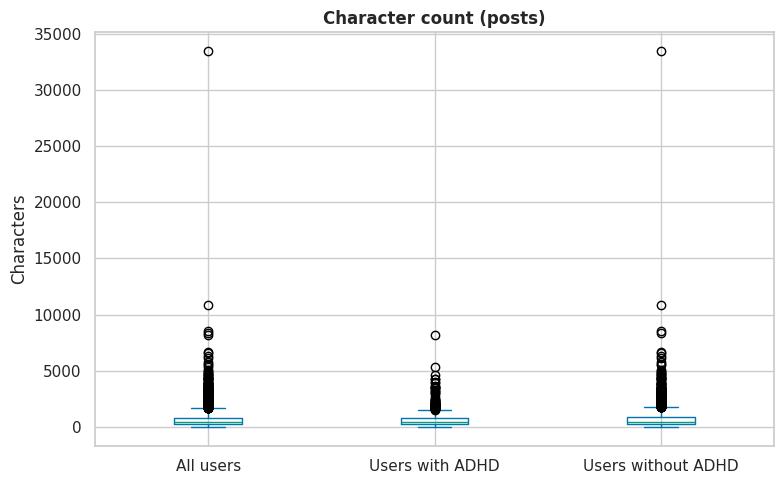

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
df_posts_len = pd.DataFrame({
    'All users':len_data_all_posts["char_count"],
    'Users with ADHD':len_data_adhd_posts["char_count"],
    'Users without ADHD':len_data_not_adhd_posts["char_count"]})

df_posts_len.plot(kind='box',ax=ax)
ax.set_title('Character count (posts)',fontweight='bold')
ax.set_ylabel('Characters')

plt.tight_layout()
plt.show()

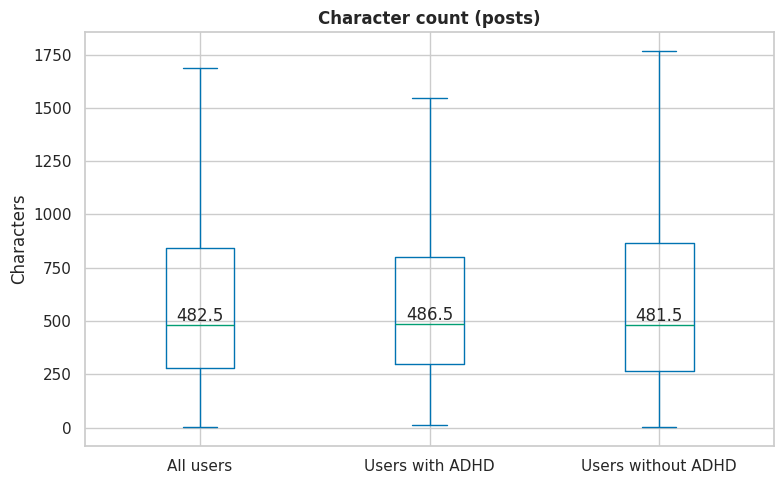

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

df_posts_len.plot(kind='box',ax=ax,showfliers=False)
ax.set_title('Character count (posts)',fontweight='bold')
ax.set_ylabel('Characters')

medians = df_posts_len.median()
for i, (col, median_val) in enumerate(medians.items(), start=1):
    ax.text(i, median_val, f'{median_val:.1f}', 
            horizontalalignment='center', verticalalignment='bottom')

plt.tight_layout()
plt.show()

## Content Analysis

### Word frequency

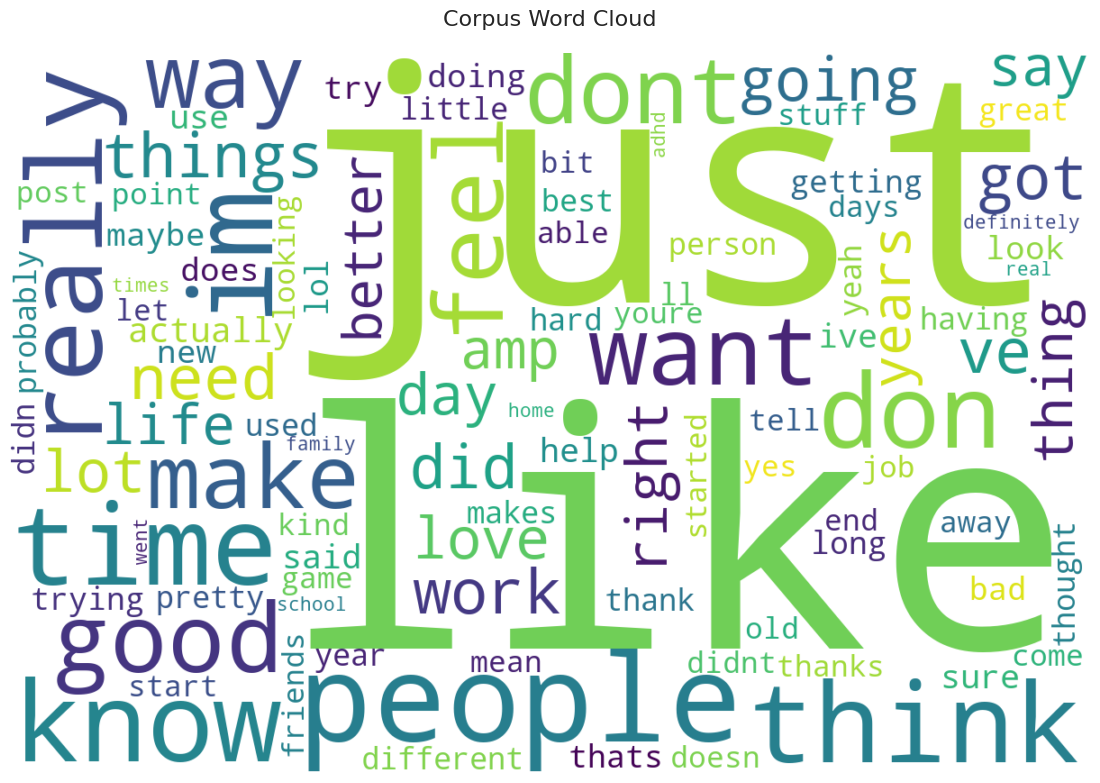

In [24]:
all_text = content_df["text"].dropna().tolist()

vectorizer = CountVectorizer(
    strip_accents="ascii",
    lowercase=True,
    stop_words="english",
    min_df=10
)

X = vectorizer.fit_transform(all_text)
feature_names = vectorizer.get_feature_names_out()

frequencies = dict(zip(feature_names, np.asarray(X.sum(axis=0)).flatten()))

wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color='white',
    max_words=100,
    colormap='viridis',
    relative_scaling=0.5
).generate_from_frequencies(frequencies)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Corpus Word Cloud', size=16, pad=20)
plt.tight_layout()
plt.show()

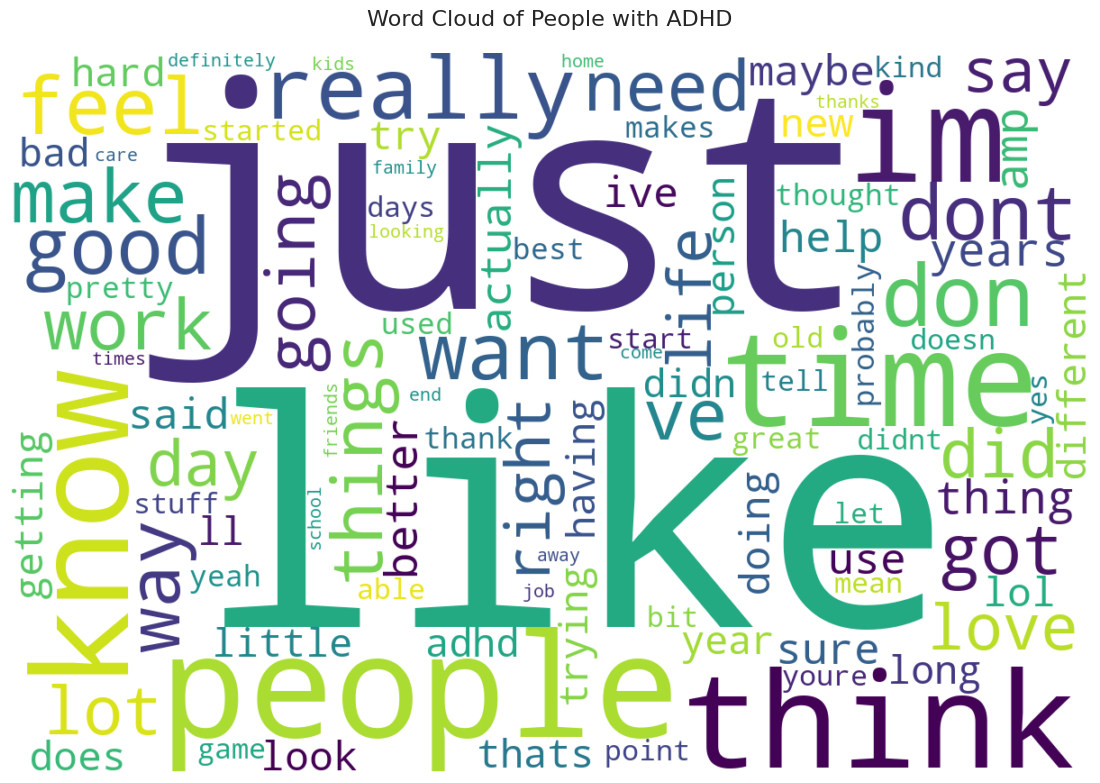

In [25]:
text_adhd = join_data.loc[join_data["has_ADHD"]==True,"text"].dropna().tolist()

vectorizer = CountVectorizer(
    strip_accents="ascii",
    lowercase=True,
    stop_words="english",
    min_df=10
)

X = vectorizer.fit_transform(text_adhd)
feature_names = vectorizer.get_feature_names_out()

frequencies = dict(zip(feature_names, np.asarray(X.sum(axis=0)).flatten()))

wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color='white',
    max_words=100,
    colormap='viridis',
    relative_scaling=0.5
).generate_from_frequencies(frequencies)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of People with ADHD', size=16, pad=20)
plt.tight_layout()
plt.show()

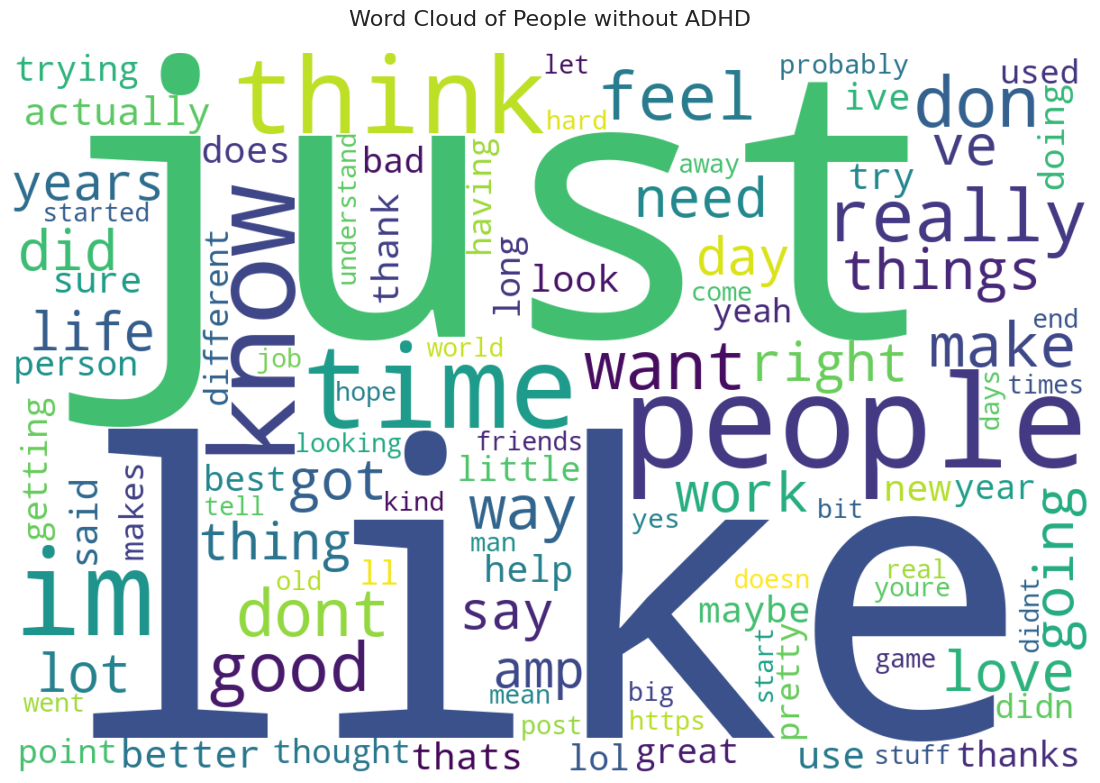

In [26]:
text_not_adhd = join_data.loc[join_data["has_ADHD"]==False,"text"].dropna().tolist()

vectorizer = CountVectorizer(
    strip_accents="ascii",
    lowercase=True,
    stop_words="english",
    min_df=10
)

X = vectorizer.fit_transform(text_not_adhd)
feature_names = vectorizer.get_feature_names_out()

frequencies = dict(zip(feature_names, np.asarray(X.sum(axis=0)).flatten()))

wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color='white',
    max_words=100,
    colormap='viridis',
    relative_scaling=0.5
).generate_from_frequencies(frequencies)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of People without ADHD', size=16, pad=20)
plt.tight_layout()
plt.show()

### Emotion and Sentiment analysis

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

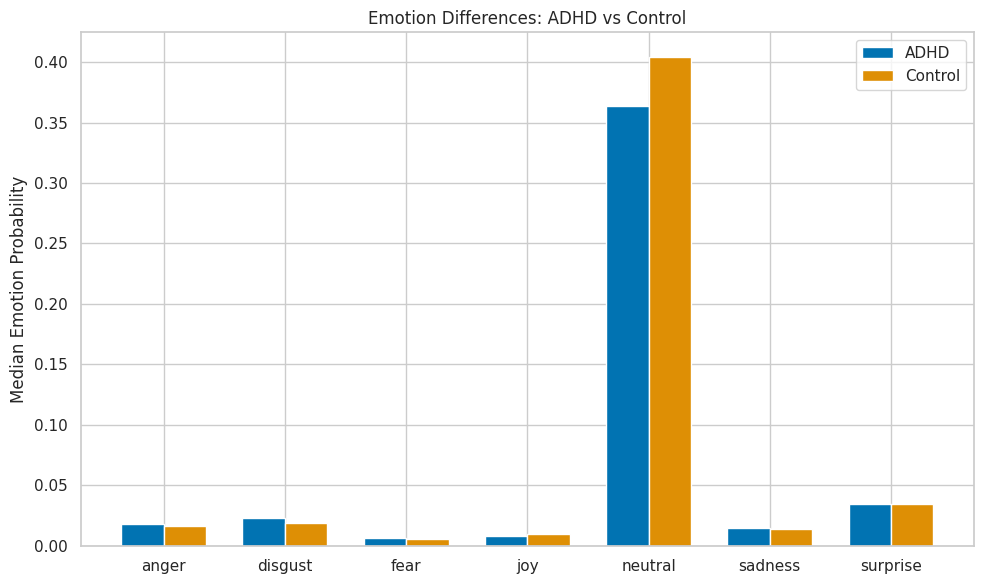

In [27]:

#cargo modelo
classifier = pipeline("text-classification", 
                      model="j-hartmann/emotion-english-distilroberta-base", 
                      top_k=None,
                      truncation=True,
                      max_length=512,
                      device=0 if torch.cuda.is_available() else -1)

emotion_labels = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

sample_size = 5000
text_adhd = join_data.loc[join_data["has_ADHD"]==True,"text"].dropna().tolist()
text_not_adhd = join_data.loc[join_data["has_ADHD"]==False,"text"].dropna().tolist()

if len(text_adhd) > sample_size:
    text_adhd = random.sample(text_adhd, sample_size)

if len(text_not_adhd) > sample_size:
    text_not_adhd = random.sample(text_not_adhd, sample_size)

all_probs = []
for text in text_adhd:
    result = classifier(text)[0]
    label_to_score = {item['label']: item['score'] for item in result}
    probs = [label_to_score[label] for label in emotion_labels]
    all_probs.append(probs)
adhd_probs = np.array(all_probs)

all_probs = []
for text in text_not_adhd:
    result = classifier(text)[0]
    label_to_score = {item['label']: item['score'] for item in result}
    probs = [label_to_score[label] for label in emotion_labels]
    all_probs.append(probs)
control_probs = np.array(all_probs)



adhd_mean = np.median(adhd_probs, axis=0)
control_mean = np.median(control_probs, axis=0)


x = np.arange(len(emotion_labels))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, adhd_mean, width, label='ADHD', capsize=5)
plt.bar(x + width/2, control_mean, width, label='Control', capsize=5)

plt.xticks(x, emotion_labels)
plt.ylabel("Median Emotion Probability")
plt.title("Emotion Differences: ADHD vs Control")
plt.legend()

plt.tight_layout()
plt.show()

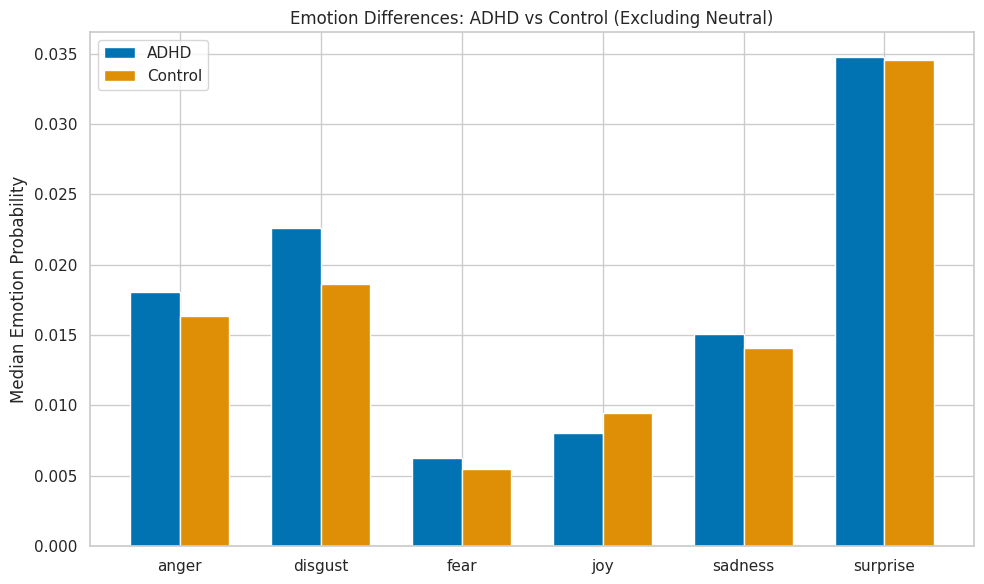

In [28]:
emotion_labels_filtered = [label for label in emotion_labels if label != 'neutral']
neutral_idx = emotion_labels.index('neutral') if 'neutral' in emotion_labels else None

if neutral_idx is not None:
    adhd_mean_filtered = np.delete(adhd_mean, neutral_idx)
    control_mean_filtered = np.delete(control_mean, neutral_idx)
else:
    adhd_mean_filtered = adhd_mean
    control_mean_filtered = control_mean

x = np.arange(len(emotion_labels_filtered))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, adhd_mean_filtered, width, label='ADHD', capsize=5)
plt.bar(x + width/2, control_mean_filtered, width, label='Control', capsize=5)

plt.xticks(x, emotion_labels_filtered)
plt.ylabel("Median Emotion Probability")
plt.title("Emotion Differences: ADHD vs Control (Excluding Neutral)")
plt.legend()

plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: j-hartmann/sentiment-roberta-large-english-3-classes
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


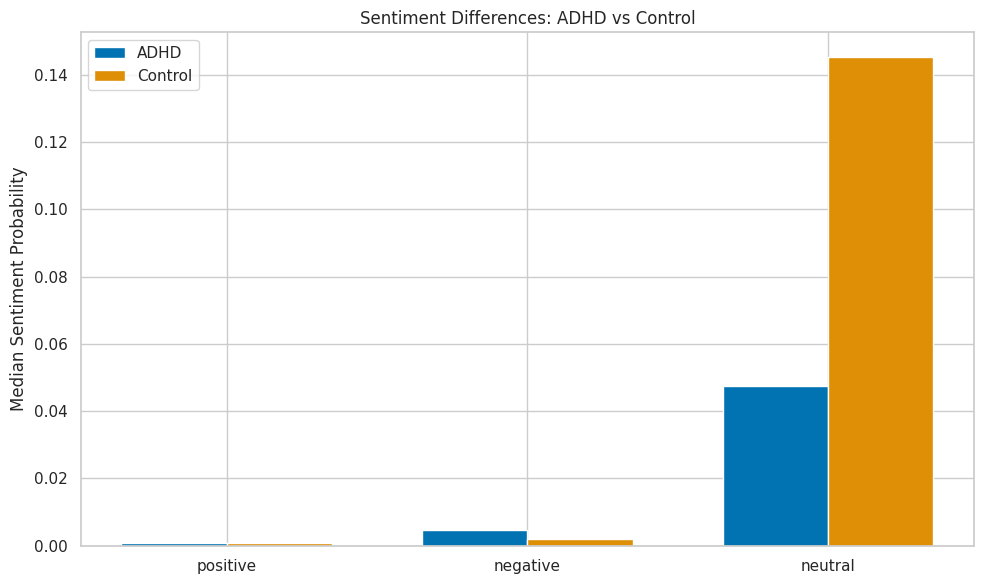

In [5]:
classifier = pipeline("text-classification", 
                      model="j-hartmann/sentiment-roberta-large-english-3-classes", 
                      top_k=None,
                      truncation=True,
                      max_length=512,
                      device=0 if torch.cuda.is_available() else -1)

emotion_labels = ['positive','negative','neutral']

sample_size = 5000
text_adhd = join_data.loc[join_data["has_ADHD"]==True,"text"].dropna().tolist()
text_not_adhd = join_data.loc[join_data["has_ADHD"]==False,"text"].dropna().tolist()

if len(text_adhd) > sample_size:
    text_adhd = random.sample(text_adhd, sample_size)

if len(text_not_adhd) > sample_size:
    text_not_adhd = random.sample(text_not_adhd, sample_size)
    
all_probs = []
for text in text_adhd:
    result = classifier(text)[0]
    label_to_score = {item['label']: item['score'] for item in result}
    probs = [label_to_score[label] for label in emotion_labels]
    all_probs.append(probs)
adhd_probs = np.array(all_probs)

all_probs = []
for text in text_not_adhd:
    result = classifier(text)[0]
    label_to_score = {item['label']: item['score'] for item in result}
    probs = [label_to_score[label] for label in emotion_labels]
    all_probs.append(probs)
control_probs = np.array(all_probs)


adhd_mean = np.median(adhd_probs, axis=0)
control_mean = np.median(control_probs, axis=0)

x = np.arange(len(emotion_labels))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, adhd_mean, width, label='ADHD', capsize=5)
plt.bar(x + width/2, control_mean, width, label='Control', capsize=5)

plt.xticks(x, emotion_labels)
plt.ylabel("Median Sentiment Probability")
plt.title("Sentiment Differences: ADHD vs Control")
plt.legend()

plt.tight_layout()
plt.show()

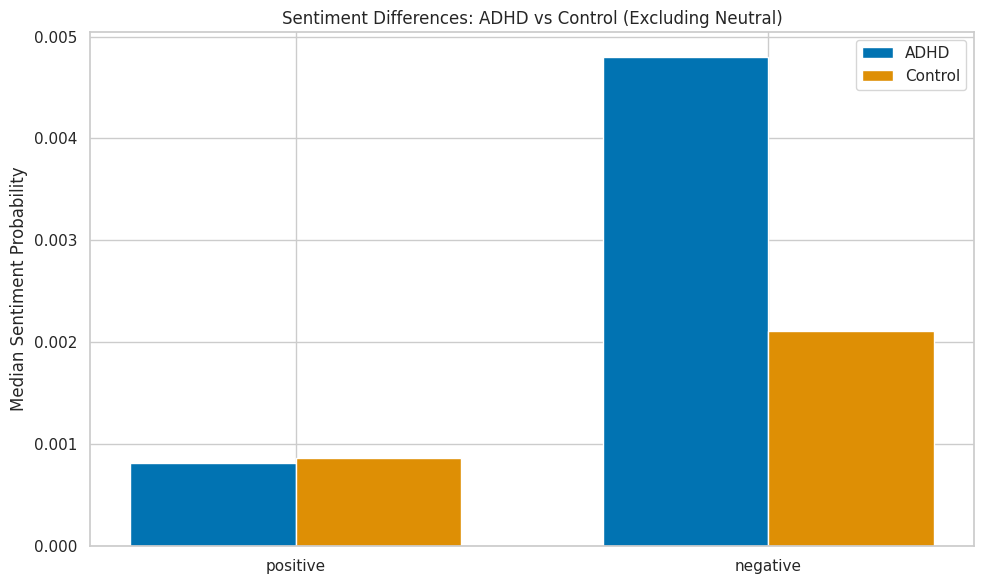

In [6]:
emotion_labels_filtered = [label for label in emotion_labels if label != 'neutral']
neutral_idx = emotion_labels.index('neutral') if 'neutral' in emotion_labels else None

if neutral_idx is not None:
    adhd_mean_filtered = np.delete(adhd_mean, neutral_idx)
    control_mean_filtered = np.delete(control_mean, neutral_idx)
else:
    adhd_mean_filtered = adhd_mean
    control_mean_filtered = control_mean

x = np.arange(len(emotion_labels_filtered))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, adhd_mean_filtered, width, label='ADHD', capsize=5)
plt.bar(x + width/2, control_mean_filtered, width, label='Control', capsize=5)

plt.xticks(x, emotion_labels_filtered)
plt.ylabel("Median Sentiment Probability")
plt.title("Sentiment Differences: ADHD vs Control (Excluding Neutral)")
plt.legend()

plt.tight_layout()
plt.show()

### Theme analysis

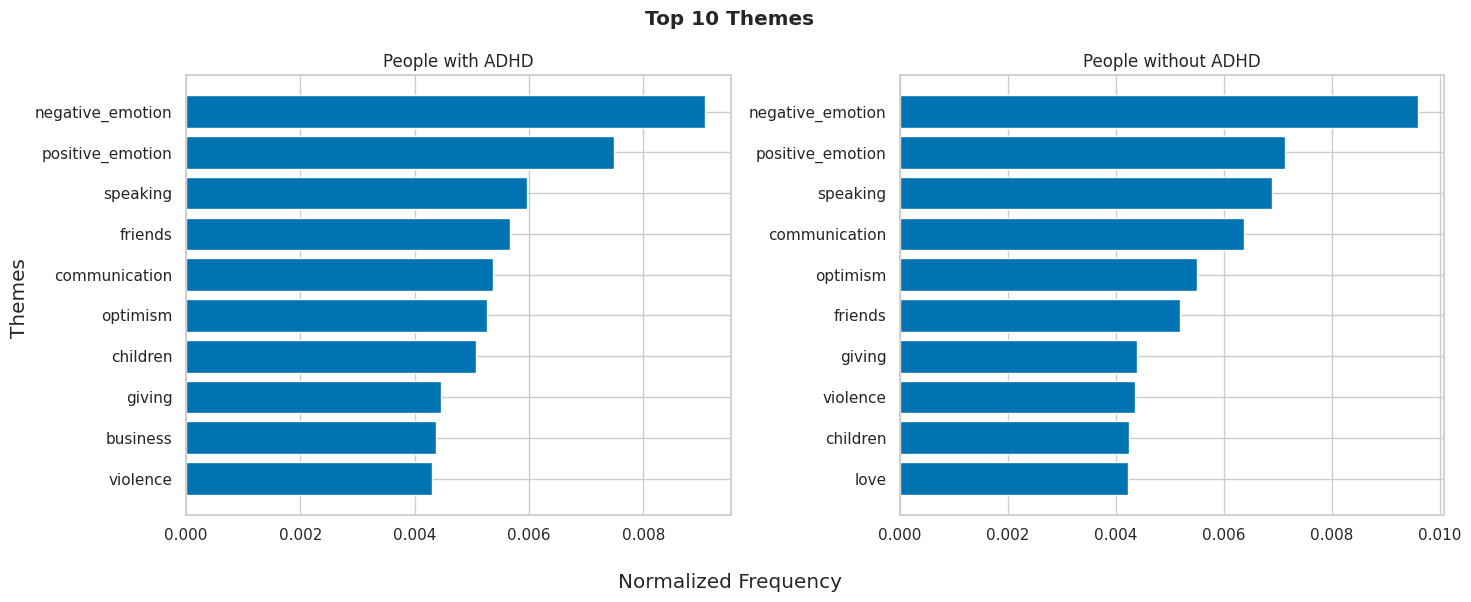

In [7]:
lexicon = Empath()

sample_size = 5000
text_adhd = join_data.loc[join_data["has_ADHD"]==True,"text"].dropna().tolist()
text_not_adhd = join_data.loc[join_data["has_ADHD"]==False,"text"].dropna().tolist()

if len(text_adhd) > sample_size:
    text_adhd = random.sample(text_adhd, sample_size)

if len(text_not_adhd) > sample_size:
    text_not_adhd = random.sample(text_not_adhd, sample_size)
    
adhd_probs = {}
for text in text_adhd:
    result = lexicon.analyze(text, normalize=True)
    for key,value in result.items():
        if key not in adhd_probs:
            adhd_probs[key] = [value]
        else:
            adhd_probs[key].append(value)

control_probs = {}
for text in text_not_adhd:
    result = lexicon.analyze(text, normalize=True)
    if not result:
        continue
    for key,value in result.items():
        if key not in control_probs:
            control_probs[key] = [value]
        else:
            control_probs[key].append(value)
         
adhd_means = {}   
for key,mylist in adhd_probs.items():
    adhd_means[key] = sum(mylist)/len(mylist)
    
control_means = {}
for key,mylist in control_probs.items():
    control_means[key] = sum(mylist)/len(mylist)
    

fig, axs = plt.subplots(1,2,figsize=(15, 6))
fig.suptitle('Top 10 Themes', fontweight='bold')

top_10_desc = dict(sorted(adhd_means.items(), key=itemgetter(1), reverse=True)[:10])
top_adhd = dict(reversed(top_10_desc.items()))

top_10_desc = dict(sorted(control_means.items(), key=itemgetter(1), reverse=True)[:10])
top_control = dict(reversed(top_10_desc.items()))

axs[0].barh(list(top_adhd.keys()), list(top_adhd.values()))
axs[1].barh(list(top_control.keys()), list(top_control.values()))

axs[0].set_title("People with ADHD")
axs[1].set_title("People without ADHD")


fig.supxlabel('Normalized Frequency')
fig.supylabel('Themes')


plt.tight_layout()
plt.show()

## Temporal Analysis

### Content quantity timeline

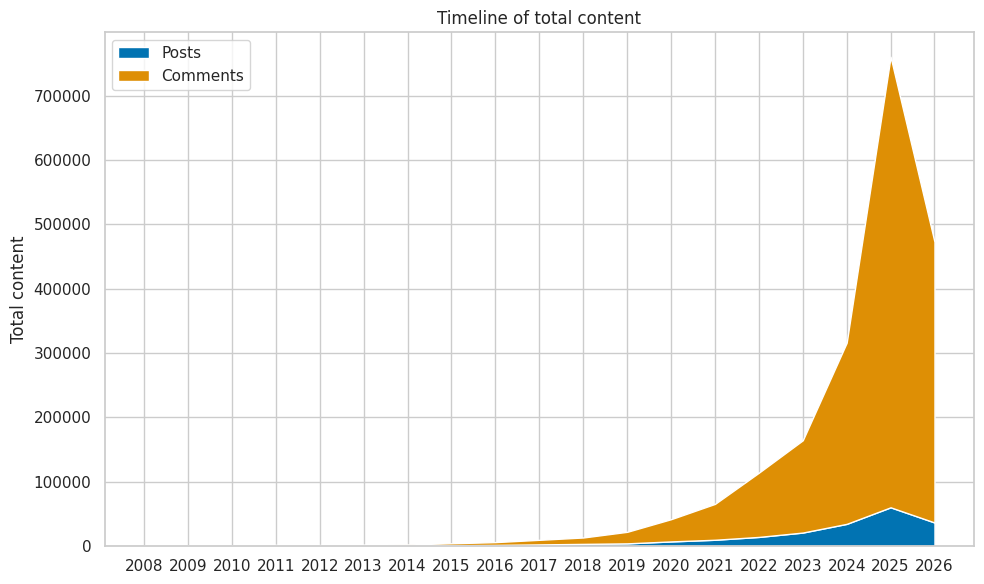

In [6]:
content_df["timestamp"] = pd.to_datetime(content_df["timestamp"],format="%Y-%m-%d %H:%M:%S%z")
contentgb = content_df.groupby([pd.Grouper(key='timestamp',freq='YE'),"type"])["id"].count().reset_index()
contentgb = contentgb.pivot(index='timestamp', columns='type', values='id').fillna(0)
contentgb = contentgb.reindex(columns=['post', 'comment'])

plt.figure(figsize=(10, 6))

years = contentgb.index.year
x = np.arange(len(years))
y = np.vstack([contentgb["post"],contentgb["comment"]])

plt.stackplot(x, y, labels=['Posts','Comments'])

plt.xticks(x,years)
plt.ylabel("Total content")
plt.title("Timeline of total content")
plt.legend()

plt.tight_layout()
plt.show()

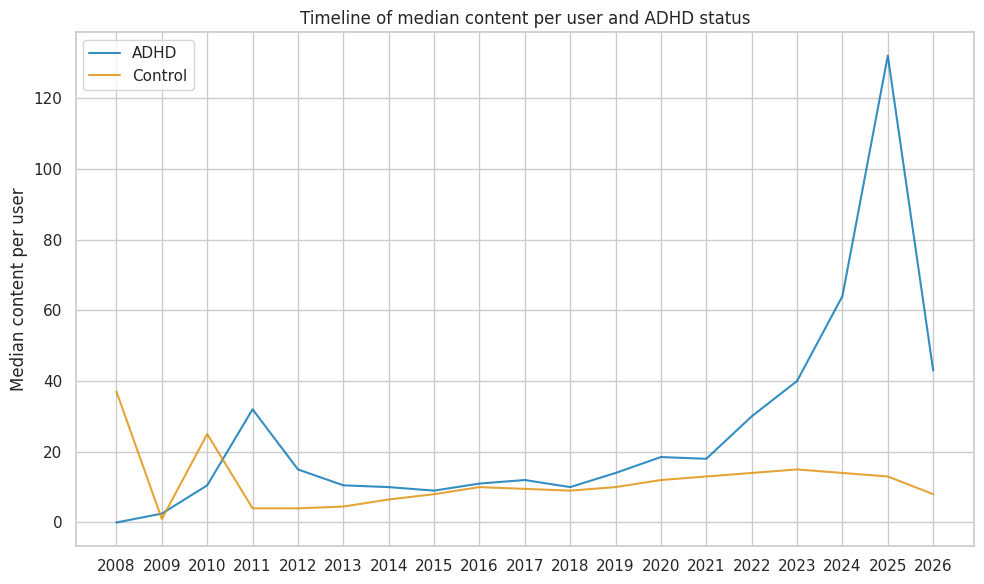

In [7]:
join_data["timestamp"] = pd.to_datetime(join_data["timestamp"], format="%Y-%m-%d %H:%M:%S%z")
join_data['year'] = join_data['timestamp'].dt.year

user_yearly_total = (join_data.groupby(['has_ADHD', 'year', 'user'])['id_y']
                     .count()
                     .reset_index())

mean_by_user = user_yearly_total.groupby(['has_ADHD', 'year'])['id_y'].median().reset_index()

adhd_mean = mean_by_user[mean_by_user['has_ADHD'] == True]
non_adhd_mean = mean_by_user[mean_by_user['has_ADHD'] == False]

years = sorted(mean_by_user['year'].unique())
x = np.arange(len(years))
width = 0.35

plt.figure(figsize=(10, 6))

#adhd
adhd_values = [adhd_mean[adhd_mean['year'] == year]['id_y'].values[0] if year in adhd_mean['year'].values else 0 for year in years]
plt.plot(x , adhd_values, label='ADHD', alpha=0.8)

#control
non_adhd_values = [non_adhd_mean[non_adhd_mean['year'] == year]['id_y'].values[0] if year in non_adhd_mean['year'].values else 0 for year in years]
plt.plot(x , non_adhd_values, label='Control', alpha=0.8)

plt.xticks(x, years)
plt.ylabel("Median content per user")
plt.title("Timeline of median content per user and ADHD status")
plt.legend()
plt.tight_layout()
plt.show()

### Content length timeline

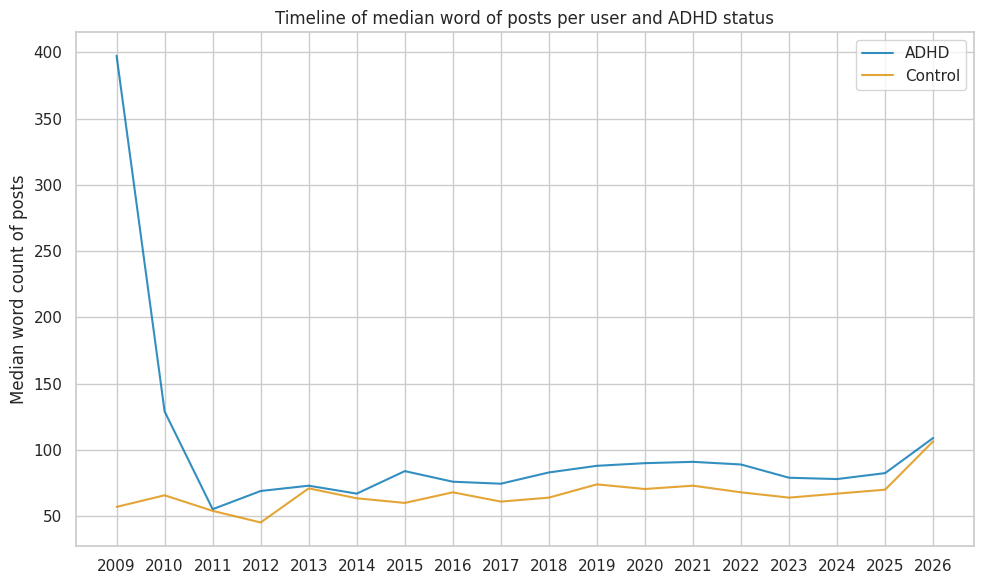

In [8]:
join_data["timestamp"] = pd.to_datetime(join_data["timestamp"], format="%Y-%m-%d %H:%M:%S%z")
join_data['year'] = join_data['timestamp'].dt.year

post_data = join_data[join_data["type"]=="post"]

user_yearly_total = (post_data.groupby(['has_ADHD', 'year', 'user'])['word_count']
                     .median()
                     .reset_index())

mean_by_user = user_yearly_total.groupby(['has_ADHD', 'year'])['word_count'].median().reset_index()

adhd_mean = mean_by_user[mean_by_user['has_ADHD'] == True]
non_adhd_mean = mean_by_user[mean_by_user['has_ADHD'] == False]

years = sorted(mean_by_user['year'].unique())
x = np.arange(len(years))
width = 0.35

plt.figure(figsize=(10, 6))

#adhd
adhd_values = [adhd_mean[adhd_mean['year'] == year]['word_count'].values[0] if year in adhd_mean['year'].values else 0 for year in years]
plt.plot(x , adhd_values, label='ADHD', alpha=0.8)

#control
non_adhd_values = [non_adhd_mean[non_adhd_mean['year'] == year]['word_count'].values[0] if year in non_adhd_mean['year'].values else 0 for year in years]
plt.plot(x , non_adhd_values, label='Control', alpha=0.8)

plt.xticks(x, years)
plt.ylabel("Median word count of posts")
plt.title("Timeline of median word of posts per user and ADHD status")
plt.legend()
plt.tight_layout()
plt.show()

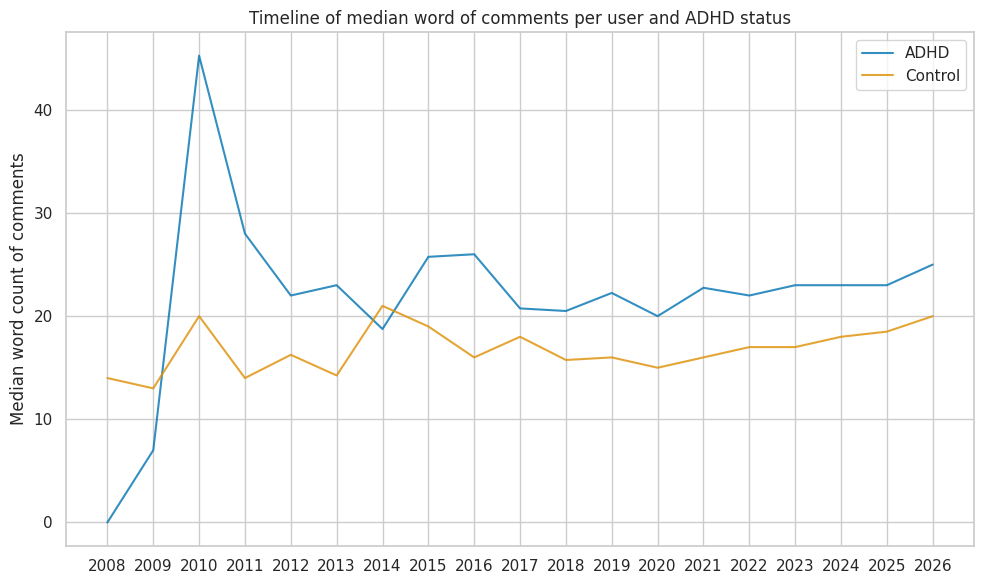

In [9]:
join_data["timestamp"] = pd.to_datetime(join_data["timestamp"], format="%Y-%m-%d %H:%M:%S%z")
join_data['year'] = join_data['timestamp'].dt.year

comment_data = join_data[join_data["type"]=="comment"]

user_yearly_total = (comment_data.groupby(['has_ADHD', 'year', 'user'])['word_count']
                     .median()
                     .reset_index())

mean_by_user = user_yearly_total.groupby(['has_ADHD', 'year'])['word_count'].median().reset_index()

adhd_mean = mean_by_user[mean_by_user['has_ADHD'] == True]
non_adhd_mean = mean_by_user[mean_by_user['has_ADHD'] == False]

years = sorted(mean_by_user['year'].unique())
x = np.arange(len(years))
width = 0.35

plt.figure(figsize=(10, 6))

#adhd
adhd_values = [adhd_mean[adhd_mean['year'] == year]['word_count'].values[0] if year in adhd_mean['year'].values else 0 for year in years]
plt.plot(x , adhd_values, label='ADHD', alpha=0.8)

#control
non_adhd_values = [non_adhd_mean[non_adhd_mean['year'] == year]['word_count'].values[0] if year in non_adhd_mean['year'].values else 0 for year in years]
plt.plot(x , non_adhd_values, label='Control', alpha=0.8)

plt.xticks(x, years)
plt.ylabel("Median word count of comments")
plt.title("Timeline of median word of comments per user and ADHD status")
plt.legend()
plt.tight_layout()
plt.show()

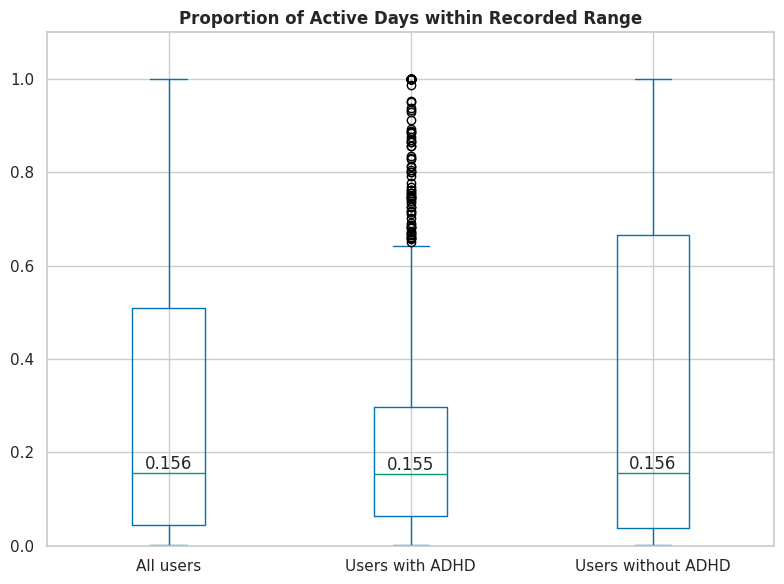

In [10]:
join_data["timestamp"] = pd.to_datetime(join_data["timestamp"], format="%Y-%m-%d %H:%M:%S%z")

usergb = join_data.groupby(["user", "has_ADHD"]).agg(
    unique_days=('timestamp', lambda x: x.dt.date.nunique()),  #numero de dias unicos con actividad
    first_content=('timestamp', lambda x: x.dt.date.min()),  #primer contenido
    last_content=('timestamp', lambda x: x.dt.date.max())    #ultimo contenido
).reset_index()

usergb['first_content'] = pd.to_datetime(usergb['first_content'])
usergb['last_content'] = pd.to_datetime(usergb['last_content'])
usergb["range"] = ((usergb['last_content'] - usergb['first_content'])).dt.days +1
usergb["per_activity"] = usergb["unique_days"]/usergb["range"]

df_per_activity = pd.DataFrame({
    'All users': usergb["per_activity"],
    'Users with ADHD': usergb.loc[usergb["has_ADHD"] == True, "per_activity"],
    'Users without ADHD': usergb.loc[usergb["has_ADHD"] == False, "per_activity"],
})

fig, ax = plt.subplots(figsize=(8, 6))
df_per_activity.plot(kind='box', ax=ax)


ax.set_title('Proportion of Active Days within Recorded Range',fontweight='bold')
ax.set_ylim(0, 1.1)

medians = df_per_activity.median()
for i, (col, median_val) in enumerate(medians.items(), start=1):
    ax.text(i, median_val, f'{median_val:.3f}', 
            horizontalalignment='center', verticalalignment='bottom')

plt.tight_layout()
plt.show()

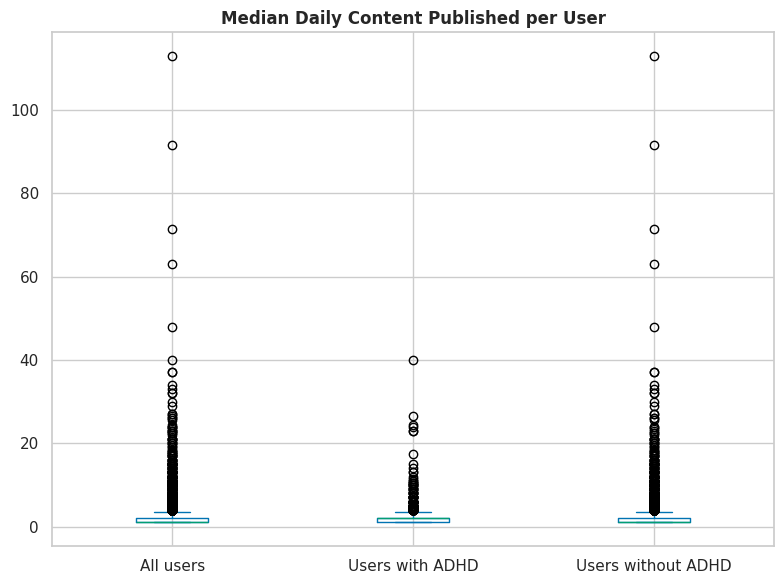

In [15]:
join_data["timestamp"] = pd.to_datetime(join_data["timestamp"], format="%Y-%m-%d %H:%M:%S%z")

daily_content = join_data.groupby(["user", "has_ADHD", join_data["timestamp"].dt.date]).size().reset_index(name='content_count')

user_median_daily = daily_content.groupby(["user", "has_ADHD"])['content_count'].median().reset_index(name='median_daily_content')

udf_median_daily = pd.DataFrame({
    'All users': user_median_daily["median_daily_content"],
    'Users with ADHD': user_median_daily.loc[user_median_daily["has_ADHD"] == True, "median_daily_content"],
    'Users without ADHD': user_median_daily.loc[user_median_daily["has_ADHD"] == False, "median_daily_content"]
})

fig, ax = plt.subplots(figsize=(8, 6))
udf_median_daily.plot(kind='box', ax=ax)


ax.set_title('Median Daily Content Published per User',fontweight='bold')


plt.tight_layout()
plt.show()

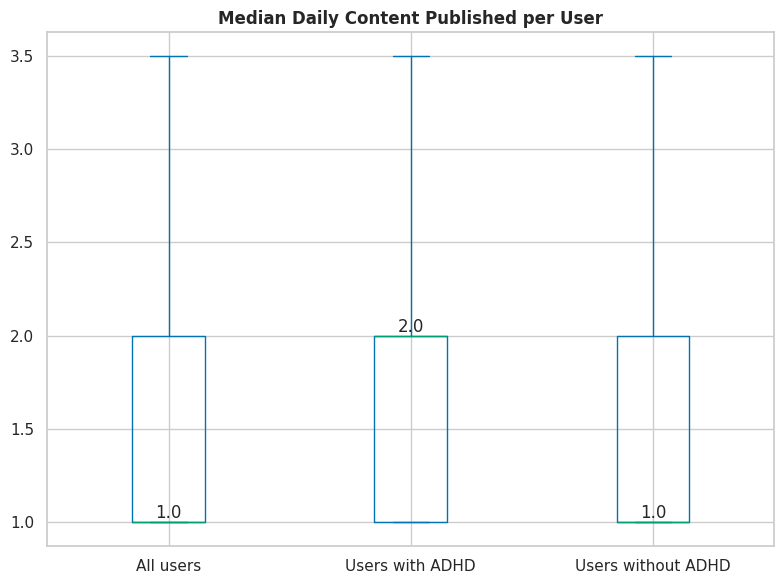

In [16]:


fig, ax = plt.subplots(figsize=(8, 6))
udf_median_daily.plot(kind='box', ax=ax,showfliers=False)


ax.set_title('Median Daily Content Published per User',fontweight='bold')

medians = udf_median_daily.median()
for i, (col, median_val) in enumerate(medians.items(), start=1):
    ax.text(i, median_val, f'{median_val:.1f}', 
            horizontalalignment='center', verticalalignment='bottom')

plt.tight_layout()
plt.show()

## Media Content Analysis

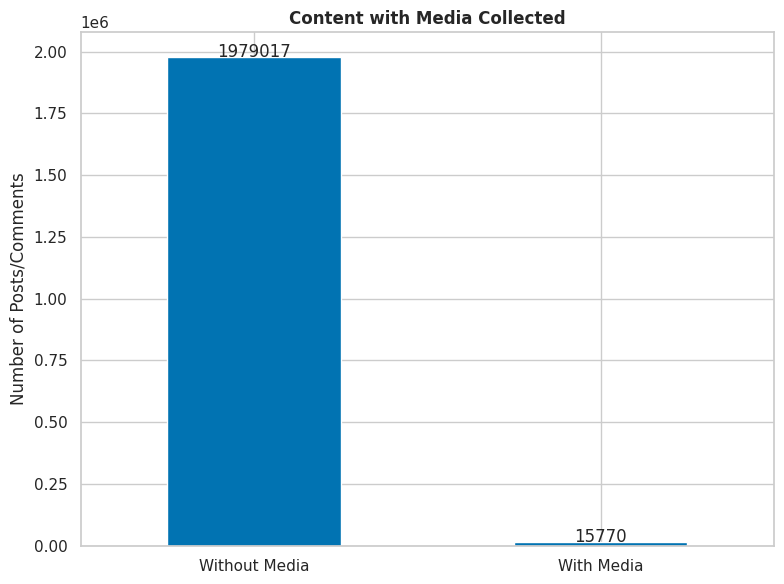

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
pattern_counts = content_df.groupby('has_media').size()
pattern_counts.index = ['Without Media' if not x else 'With Media' for x in pattern_counts.index]
bars = pattern_counts.plot(kind='bar', ax=ax)
ax.set_title('Content with Media Collected', fontweight='bold')
ax.set_ylabel('Number of Posts/Comments')
ax.tick_params(axis='x', rotation=0)

for i, v in enumerate(pattern_counts.values):
    ax.text(i, v + 0.1, str(v), ha='center')

plt.tight_layout()
plt.show()

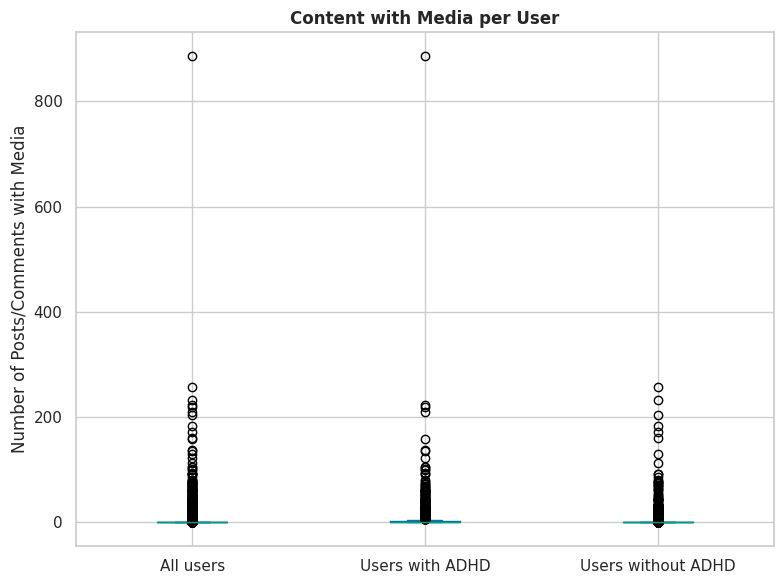

In [18]:
media_posts = join_data.groupby('user')['has_media'].sum().reset_index(name='media_count')

users_adhd = join_data[['user', 'has_ADHD']].drop_duplicates()
media_posts = media_posts.merge(users_adhd, on='user')

fig, ax = plt.subplots(figsize=(8, 6))
df_media_count = pd.DataFrame({
    'All users': media_posts['media_count'],
    'Users with ADHD': media_posts[media_posts['has_ADHD']==True]['media_count'],
    'Users without ADHD': media_posts[media_posts['has_ADHD']==False]['media_count']
})

df_media_count.plot(kind='box', ax=ax)
ax.set_title('Content with Media per User', fontweight='bold')
ax.set_ylabel('Number of Posts/Comments with Media')


plt.tight_layout()
plt.show()

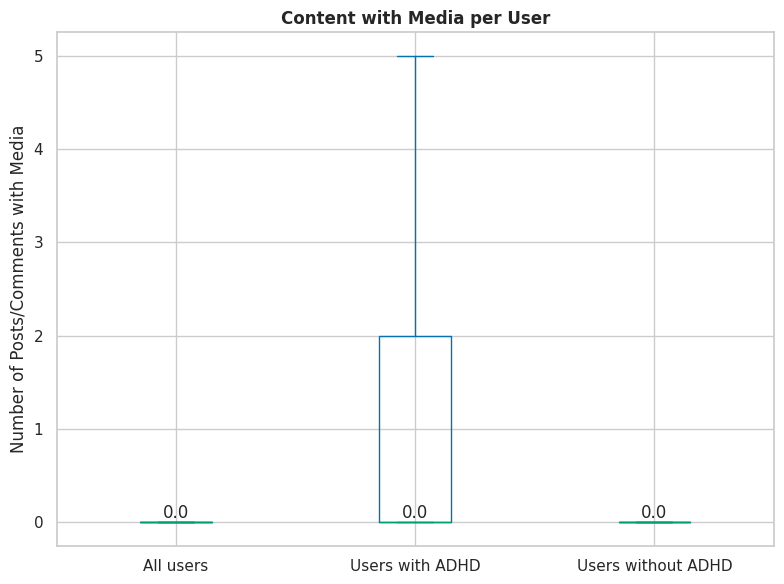

In [19]:
media_posts = join_data.groupby('user')['has_media'].sum().reset_index(name='media_count')

users_adhd = join_data[['user', 'has_ADHD']].drop_duplicates()
media_posts = media_posts.merge(users_adhd, on='user')

fig, ax = plt.subplots(figsize=(8, 6))
df_media_count = pd.DataFrame({
    'All users': media_posts['media_count'],
    'Users with ADHD': media_posts[media_posts['has_ADHD']==True]['media_count'],
    'Users without ADHD': media_posts[media_posts['has_ADHD']==False]['media_count']
})

df_media_count.plot(kind='box', ax=ax,showfliers=False)
ax.set_title('Content with Media per User', fontweight='bold')
ax.set_ylabel('Number of Posts/Comments with Media')

medians = df_media_count.median()
for i, (col, median_val) in enumerate(medians.items(), start=1):
    ax.text(i, median_val, f'{median_val:.1f}', 
            horizontalalignment='center', verticalalignment='bottom')

plt.tight_layout()
plt.show()

Top 10 Subreddits by Media Content Percentage:
 1. r/CRFla                   100.0% media (29/29 posts)
 2. r/fussball                100.0% media (30/30 posts)
 3. r/computadores             94.7% media (18/19 posts)
 4. r/F1Brasil                 94.1% media (16/17 posts)
 5. r/AnimeSketch              91.4% media (53/58 posts)
 6. r/Filme                    82.4% media (14/17 posts)
 7. r/monopolygo_fairtrade     81.8% media (9/11 posts)
 8. r/Manhua                   78.3% media (144/184 posts)
 9. r/Klussers                 75.7% media (28/37 posts)
10. r/transtrade               72.2% media (13/18 posts)


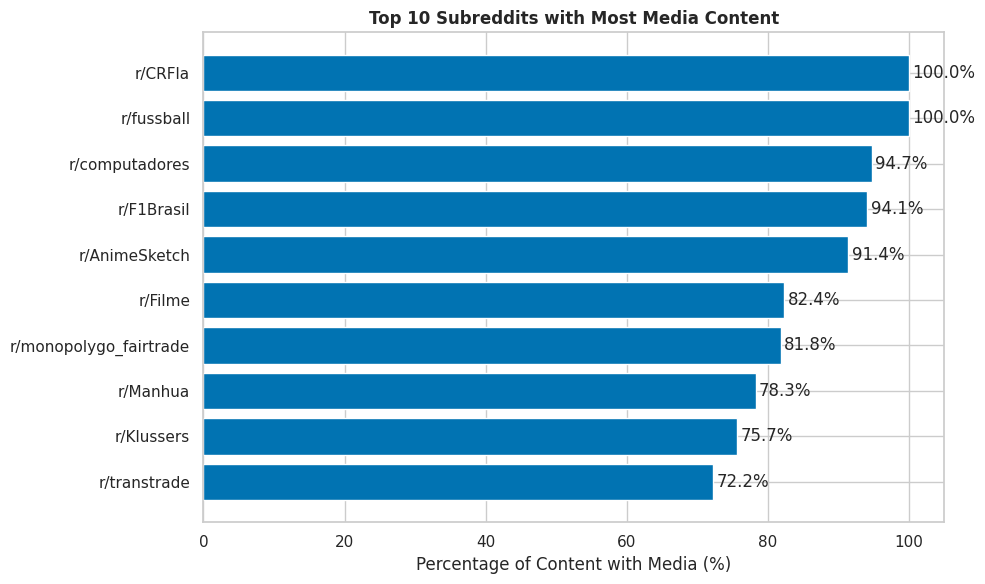

In [20]:
content_df_filtered = content_df[content_df['subreddit'].str.startswith('r/', na=False)]

subreddit_media = content_df_filtered.groupby('subreddit').agg(
    total_posts=('has_media', 'count'),
    media_posts=('has_media', 'sum')
).reset_index()

subreddit_media['media_percentage'] = (subreddit_media['media_posts'] / subreddit_media['total_posts'] * 100)

min_posts = 10
subreddit_media_filtered = subreddit_media[subreddit_media['total_posts'] >= min_posts]

top_10_media = subreddit_media_filtered.nlargest(10, 'media_percentage')

print("Top 10 Subreddits by Media Content Percentage:")
print("=" * 60)
for i, row in enumerate(top_10_media.itertuples(), 1):
    print(f"{i:2d}. {row.subreddit:<25s} {row.media_percentage:5.1f}% media "
          f"({row.media_posts:.0f}/{row.total_posts:.0f} posts)")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(10), top_10_media['media_percentage'].values)
ax.set_yticks(range(10))
ax.set_yticklabels(top_10_media['subreddit'].values)
ax.invert_yaxis()
ax.set_xlabel('Percentage of Content with Media (%)')
ax.set_title('Top 10 Subreddits with Most Media Content', fontweight='bold')

for i, (bar, pct) in enumerate(zip(bars, top_10_media['media_percentage'].values)):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{pct:.1f}%', va='center')

plt.tight_layout()
plt.show()